In [7]:
from transformers import BertForQuestionAnswering
from transformers import BertTokenizer
import torch

In [11]:
model_name = "bert-large-uncased-whole-word-masking-finetuned-squad" # uncased measn both upeer and lower case are considered as samw

In [10]:
model = BertForQuestionAnswering.from_pretrained(model_name)

config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

C:\Users\moham\anaconda3\envs\llms_course_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\moham\.cache\huggingface\hub\models--bert-large-uncased-whole-word-masking-finetuned-squad. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for this repo, but the 'hf_xet' package is not 

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [55]:
tokenizer = BertTokenizer.from_pretrained(model_name) # speiofied the model we wwant to use the tokenizer for 

## create some embeddings using this tokenizer.



In [15]:
#example question and text contaioning the answer
question = "When was the first dvd released"
answer_document = "The first DVD (Digital Versatile Disc) was released on March 24, 1997. It was a movie titled 'Twister' and was released in Japan. DVDs quickly gained popularity as a replacement for VHS tapes and became a common format for storing and distributing digital video and data. Sunset Motors is a renowned automobile dealership that has been a cornerstone of the automotive industry since its establishment in 1978. Located in the picturesque town of Crestwood, nestled in the heart of California's scenic Central Valley, Sunset Motors has built a reputation for excellence, reliability, and customer satisfaction over the past four decades. Founded by visionary entrepreneur Robert Anderson, Sunset Motors began as a humble, family-owned business with a small lot of used cars. However, under Anderson's leadership and commitment to quality, it quickly evolved into a thriving dealership offering a wide range of vehicles from various manufacturers. Today, the dealership spans over 10 acres, showcasing a vast inventory of new and pre-owned cars, trucks, SUVs, and luxury vehicles. One of Sunset Motors' standout features is its dedication to sustainability. In 2010, the dealership made a landmark decision to incorporate environmentally friendly practices, including solar panels to power the facility, energy-efficient lighting, and a comprehensive recycling program. This commitment to eco-consciousness has earned Sunset Motors recognition as an industry leader in sustainable automotive retail. Sunset Motors proudly offers a diverse range of vehicles, including popular brands like Ford, Toyota, Honda, Chevrolet, and BMW, catering to a wide spectrum of tastes and preferences. In addition to its outstanding vehicle selection, Sunset Motors offers flexible financing options, allowing customers to secure affordable loans and leases with competitive interest rates."

In [16]:
encoding = tokenizer.encode_plus(text=question, text_pair=answer_document  )

In [17]:
print(encoding)

{'input_ids': [101, 2043, 2001, 1996, 2034, 4966, 2207, 102, 1996, 2034, 4966, 1006, 3617, 22979, 5860, 1007, 2001, 2207, 2006, 2233, 2484, 1010, 2722, 1012, 2009, 2001, 1037, 3185, 4159, 1005, 9792, 2121, 1005, 1998, 2001, 2207, 1999, 2900, 1012, 22477, 2855, 4227, 6217, 2004, 1037, 6110, 2005, 17550, 13324, 1998, 2150, 1037, 2691, 4289, 2005, 23977, 1998, 20083, 3617, 2678, 1998, 2951, 1012, 10434, 9693, 2003, 1037, 8228, 9935, 16743, 5605, 2008, 2038, 2042, 1037, 23354, 1997, 1996, 12945, 3068, 2144, 2049, 5069, 1999, 3301, 1012, 2284, 1999, 1996, 23273, 2237, 1997, 11146, 3702, 1010, 22704, 1999, 1996, 2540, 1997, 2662, 1005, 1055, 12916, 2430, 3028, 1010, 10434, 9693, 2038, 2328, 1037, 5891, 2005, 8012, 1010, 15258, 1010, 1998, 8013, 9967, 2058, 1996, 2627, 2176, 5109, 1012, 2631, 2011, 28036, 10670, 2728, 5143, 1010, 10434, 9693, 2211, 2004, 1037, 15716, 1010, 2155, 1011, 3079, 2449, 2007, 1037, 2235, 2843, 1997, 2109, 3765, 1012, 2174, 1010, 2104, 5143, 1005, 1055, 4105, 1998, 8

In [19]:
inputs = encoding['input_ids']
sentence_embedding = encoding['token_type_ids']
tokens = tokenizer.convert_ids_to_tokens(inputs)

In [20]:
tokenizer.decode(101)

'[CLS]'

In [21]:
tokenizer.decode(103)

'[MASK]'

In [23]:
tokenizer.decode(102)

'[SEP]'

### FIRST CONVERT THE EMBEDDING INTO TENSOR FORMAT AND PASS TO THE MODEL

In [25]:
output = model(input_ids= torch.tensor([inputs]), token_type_ids= torch.tensor([sentence_embedding]))

### we want to get the start and end token positions from our output
### MODEL OUTPUT

In [26]:
start_index = torch.argmax(output.start_logits)
end_index = torch.argmax(output.end_logits)

print(start_index, end_index)

tensor(19) tensor(22)


In [29]:
#The answer in our text starts at token 20 and we'll end at token 23
# So let's use this below to pull the correct tokens and get our response

In [31]:
answer = ' '.join(tokens[start_index:end_index+1])
print(answer)

march 24 , 1997


So our Bert model has worked here.

It's found the correct response in our answer document.

## Let's visualize the different tokens and their probability of being selected as the start or end token.
### We then want to find the scores for each token, pull them out of PyTorch tensors and convert them to numpy array

In [45]:
import matplotlib as plt
import seaborn as sns

In [46]:
# Next, let's create a bar plot showing the start word score for all of the tokens.
# And then start bar plot and X will be our token labels and Y will be our start scores.
# We then want to turn the x axis labels vertical.
#So we want to set x tick labels and set the rotation to 90.

In [47]:
#  for our start scores we want to take the outputs the start logits, detach them, run numpy, and then flatten them to convert these into a numpy array

start_scores = output.start_logits.detach().numpy().flatten()
end_scores = output.end_logits.detach().numpy().flatten()

In [48]:
# We'll be using the tokens as x axis labels. In order to do that, they all need to be unique. (So we'll add the token index to the end of each one of them.)

In [49]:
token_labels = []
for (i, token) in enumerate(tokens):
    token_labels.append('{:} - {:>2}'.format(token, i))

C:\Users\moham\AppData\Local\Temp\ipykernel_17184\1488797725.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


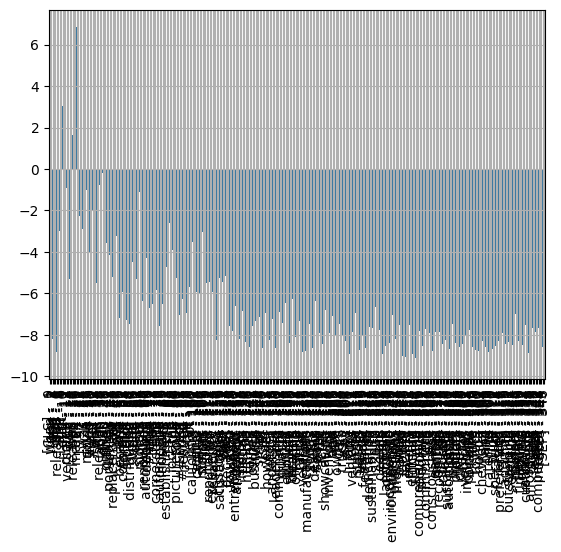

In [53]:
ax = sns.barplot(x=token_labels, y=start_scores)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
ax.grid(True)

C:\Users\moham\AppData\Local\Temp\ipykernel_17184\1375547986.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")


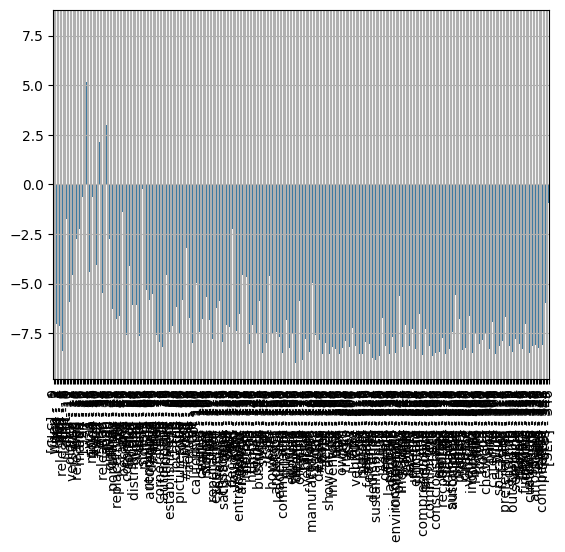

In [54]:
ax = sns.barplot(x=token_labels, y=end_scores)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha="center")
ax.grid(True)

## BERT --->> RoBERTa, DistilBERT

In [57]:
from transformers import RobertaTokenizer, RobertaModel
model_name = "roberta-base"
tokenizer = RobertaTokenizer.from_pretrained(model_name)
model = RobertaModel.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

C:\Users\moham\anaconda3\envs\llms_course_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\moham\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [58]:
from transformers import DistilBertTokenizer, DistilBertModel
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertModel.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\moham\anaconda3\envs\llms_course_env\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\moham\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]